# NER Evaluation

**Goal:** compare project scispaCy `en_ner_bc5cdr_md` (DISEASE / CHEMICAL) against the spaCy `en_core_web_sm` baseline on the BC5CDR test split (5,713 sequences after dedup).

**Metrics:**

1. **Exact match**: predicted (label, char-span) must equal a gold (label, char-span). Primary metric.
2. **Span-agnostic**: predicted character-span overlaps a gold span (label ignored). Fairness check for the baseline, whose label set (PERSON/GPE/ORG/...) does not overlap with BC5CDR's clinical labels.

**Outputs:** all metrics print inline in this notebook -- no separate result files are written.


In [1]:
import json
import sys
import time
from collections import Counter
from pathlib import Path

import pandas as pd

# Project import
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import spacy
from tqdm.auto import tqdm

from src.utils.config import NER_EVAL_DATA, NER_MODEL, RESULTS_DIR
from src.pipeline import (
    ner as scispacy_ner,
)  # uses the project wrapper (same model that runs in the UI)

c:\Users\Admin\anaconda3\Lib\site-packages\spacy\language.py:2195: FutureWarning: Possible set union at position 6328
  deserializers["tokenizer"] = lambda p: self.tokenizer.from_disk(  # type: ignore[union-attr]


In [2]:
# Load BC5CDR test split
rows = []
with open(NER_EVAL_DATA["test"], encoding="utf-8") as f:
    for line in f:
        rows.append(json.loads(line))

print(f"Loaded {len(rows):,} sequences")
print("Example:", rows[0])

Loaded 5,713 sequences
Example: {'id': 'bc5cdr_test_00000', 'text': 'Famotidine - associated delirium .', 'split': 'test', 'tokens': ['Famotidine', '-', 'associated', 'delirium', '.'], 'tags': [1, 0, 0, 2, 0], 'n_tokens': 5, 'n_disease': 1, 'n_chemical': 1, 'label_scheme': 'O=0,B-CHEMICAL=1,B-DISEASE=2,I-DISEASE=3,I-CHEMICAL=4'}


## Inspecting the test set


In [3]:
# First 10 rows as a table -- shows id, raw text, and per-sequence entity counts
preview = pd.DataFrame(
    [
        {
            "id": r["id"],
            "text": r["text"][:80] + ("..." if len(r["text"]) > 80 else ""),
            "n_tokens": r["n_tokens"],
            "n_disease": r["n_disease"],
            "n_chemical": r["n_chemical"],
        }
        for r in rows[:10]
    ]
)
preview

,id,text,n_tokens,n_disease,n_chemical
0,bc5cdr_test_00000,Famotidine - associated delirium .,5,1,1
1,bc5cdr_test_00001,A series of six cases .,6,0,0
2,bc5cdr_test_00002,Famotidine is a histamine H2 - receptor antago...,28,1,1
3,bc5cdr_test_00003,Although all of the currently available H2 - r...,29,1,1
4,bc5cdr_test_00004,The authors report on six cases of famotidine ...,22,1,2
5,bc5cdr_test_00005,The pharmacokinetics of famotidine are reviewe...,19,0,1
6,bc5cdr_test_00006,The implications of using famotidine,5,0,1
7,bc5cdr_test_00007,Indomethacin induced hypotension in sodium and...,10,1,2
8,bc5cdr_test_00008,After a single oral dose of 4 mg / kg indometh...,36,0,3
9,bc5cdr_test_00009,In sodium repleted animals indomethacin did no...,21,0,2


In [4]:
# Per-sequence length distribution (tokens) -- tells us the scale of inputs the models see
length_stats = pd.Series([r["n_tokens"] for r in rows], name="tokens_per_sequence")
print(length_stats.describe().round(1).to_string())

count    5713.0
mean       20.3
std        13.7
min         1.0
25%        11.0
50%        18.0
75%        26.0
max       135.0


In [5]:
# Total count of each BIO tag across the test set
# Useful sanity check that load + label_scheme were interpreted correctly.
# TAG_NAMES is also defined in a later cell; we duplicate it inline here so this preview
# cell stays runnable on its own without forward-referencing the BIO decoding section.
_TAG_NAMES = {0: "O", 1: "B-CHEMICAL", 2: "B-DISEASE", 3: "I-DISEASE", 4: "I-CHEMICAL"}

tag_counter = Counter()
for r in rows:
    for tag_id in r["tags"]:
        tag_counter[_TAG_NAMES[tag_id]] += 1

total = sum(tag_counter.values())
print(f"{'tag':<12}{'count':>10}{'share':>10}")
for tag in ["O", "B-DISEASE", "I-DISEASE", "B-CHEMICAL", "I-CHEMICAL"]:
    n = tag_counter[tag]
    print(f"{tag:<12}{n:>10,}{n/total:>9.1%}")
print(f"{'total':<12}{total:>10,}")

tag              count     share
O              103,171    89.1%
B-DISEASE        4,424     3.8%
I-DISEASE        2,424     2.1%
B-CHEMICAL       5,381     4.6%
I-CHEMICAL         401     0.3%
total          115,801


## BIO -> character-offset spans

BC5CDR stores annotations **per token** using the BIO tagging scheme. Our spaCy models, however, return entities as **character-level spans** of the original text. We need to convert one into the other so the two can be compared directly.

### Step 1: what BIO means

Each token in a sequence carries one tag:

| Prefix | Meaning                                                                                |
| ------ | -------------------------------------------------------------------------------------- |
| `B-X`  | **B**eginning of a new entity of type X                                                |
| `I-X`  | **I**nside an entity of type X (must follow a `B-X` or another `I-X` of the same type) |
| `O`    | **O**utside any entity                                                                 |

So the tag sequence `[B-CHEMICAL, O, O, B-DISEASE, O]` over tokens `["Famotidine", "-", "associated", "delirium", "."]` describes two entities:

- a CHEMICAL covering token 0 (`Famotidine`)
- a DISEASE covering token 3 (`delirium`)

Multi-token entities look like `[B-DISEASE, I-DISEASE]` over e.g. `["heart", "failure"]`.

### Step 2: turning token indices into character offsets

The cleaned BC5CDR text is built as `text = ' '.join(tokens)`. Because tokens are joined with a single space, the character span of token `i` is:

```
start_i = sum(len(tokens[j]) + 1 for j in range(i))   # +1 for each preceding space
end_i   = start_i + len(tokens[i])
```

For our example sentence `"Famotidine - associated delirium ."` the offsets are:

|   i | token        | start | end |
| --: | ------------ | ----: | --: |
|   0 | `Famotidine` |     0 |  10 |
|   1 | `-`          |    11 |  12 |
|   2 | `associated` |    13 |  23 |
|   3 | `delirium`   |    24 |  32 |
|   4 | `.`          |    33 |  34 |

### Step 3: BIO -> entity spans

We walk the tag sequence left-to-right. When we hit `B-X`, we open a new span starting at that token's character offset. While we keep seeing `I-X` of the _same_ type, we extend the open span's end. When we hit `O` or a different label, we close the current span. The final span (if still open at end of sequence) is also closed.

The result is a list like `{"label": "CHEMICAL", "start": 0, "end": 10}` -- the same shape spaCy returns for its predicted entities, which makes scoring trivial.


In [6]:
# Numeric tag id -> human label, per the BC5CDR label_scheme field
TAG_NAMES = {0: "O", 1: "B-CHEMICAL", 2: "B-DISEASE", 3: "I-DISEASE", 4: "I-CHEMICAL"}


def token_char_offsets(tokens):
    """For tokens joined with single spaces, return (start, end) char offsets per token.

    Example:
        tokens = ["ab", "cd"]  ->  text = "ab cd"  ->  [(0, 2), (3, 5)]
    """
    offsets = []
    pos = 0  # running character cursor in the joined text
    for tok in tokens:
        start = pos
        end = pos + len(tok)
        offsets.append((start, end))
        pos = end + 1  # +1 accounts for the single space inserted between tokens
    return offsets


def bio_to_spans(tokens, tag_ids):
    """Decode a BIO tag sequence into entity spans with character offsets.

    Walks tokens left-to-right, opening a span on every B-X tag and extending it
    while subsequent tags are I-X of the same type. Any other tag (O, or an
    I-tag whose type does not match the open span) closes the current span.
    Returns a list of {"label", "start", "end"} dicts -- the same shape spaCy
    emits for its predicted entities.
    """
    offsets = token_char_offsets(tokens)
    spans = []
    cur_label = None  # type of the currently-open entity, or None if no entity is open
    cur_start = None  # char offset where the currently-open entity began
    cur_end = None  # char offset just past the last token of the currently-open entity

    for i, tag_id in enumerate(tag_ids):
        tag = TAG_NAMES[tag_id]

        if tag.startswith("B-"):
            # New entity begins: close the previous one (if any), then start a fresh span
            if cur_label is not None:
                spans.append({"label": cur_label, "start": cur_start, "end": cur_end})
            cur_label = tag.split("-")[1]
            cur_start, cur_end = offsets[i]

        elif tag.startswith("I-") and cur_label == tag.split("-")[1]:
            # Continuation of the open entity: stretch its end forward to include this token
            cur_end = offsets[i][1]

        else:
            # O tag, or an I-tag whose type does not match -> the current span ends here
            if cur_label is not None:
                spans.append({"label": cur_label, "start": cur_start, "end": cur_end})
                cur_label = None

    # Flush the final span if the sequence ended while one was still open
    if cur_label is not None:
        spans.append({"label": cur_label, "start": cur_start, "end": cur_end})

    return spans


# Sanity check: every decoded span, sliced out of the original text, should be the entity surface form
r0 = rows[0]
spans0 = bio_to_spans(r0["tokens"], r0["tags"])
for s in spans0:
    s["text"] = r0["text"][s["start"] : s["end"]]
print("text:", r0["text"])
print("gold spans:", spans0)

text: Famotidine - associated delirium .
gold spans: [{'label': 'CHEMICAL', 'start': 0, 'end': 10, 'text': 'Famotidine'}, {'label': 'DISEASE', 'start': 24, 'end': 32, 'text': 'delirium'}]


In [7]:
# Build the gold list for every row
gold = [bio_to_spans(r["tokens"], r["tags"]) for r in rows]
n_gold_total = sum(len(g) for g in gold)
n_gold_disease = sum(1 for g in gold for s in g if s["label"] == "DISEASE")
n_gold_chemical = sum(1 for g in gold for s in g if s["label"] == "CHEMICAL")
print(
    f"Gold spans  total: {n_gold_total:,}  |  DISEASE: {n_gold_disease:,}  |  CHEMICAL: {n_gold_chemical:,}"
)

Gold spans  total: 9,805  |  DISEASE: 4,424  |  CHEMICAL: 5,381


In [8]:
# Show 3 sample rows with their gold entities surrounded by [brackets] inline -- a sanity check
# that bio_to_spans returned offsets that line up with the source text.
def highlight(text, spans):
    """Insert [LABEL: ...] markers around each span in `text`."""
    out = []
    cursor = 0
    for s in sorted(spans, key=lambda x: x["start"]):
        out.append(text[cursor : s["start"]])
        out.append(f"[{s['label']}: {text[s['start']:s['end']]}]")
        cursor = s["end"]
    out.append(text[cursor:])
    return "".join(out)


# Pick 3 sequences that actually have at least one entity each (skip the all-O ones)
samples = [(r, g) for r, g in zip(rows, gold) if g][:3]
for r, g in samples:
    print(highlight(r["text"], g))
    print()

[CHEMICAL: Famotidine] - associated [DISEASE: delirium] .

[CHEMICAL: Famotidine] is a histamine H2 - receptor antagonist used in inpatient settings for prevention of stress [DISEASE: ulcers] and is showing increasing popularity because of its low cost .

Although all of the currently available H2 - receptor antagonists have shown the propensity to cause [DISEASE: delirium] , only two previously reported cases have been associated with [CHEMICAL: famotidine] .



## Load models and run predictions


In [9]:
# Baseline: spaCy en_core_web_sm (general-domain NER)
baseline_nlp = spacy.load(
    "en_core_web_sm", disable=["tagger", "parser", "lemmatizer", "attribute_ruler"]
)
print("baseline loaded:", baseline_nlp.meta["name"], baseline_nlp.meta["version"])
print("baseline labels:", sorted(baseline_nlp.get_pipe("ner").labels))
print("scispaCy model:", NER_MODEL)

c:\Users\Admin\anaconda3\Lib\site-packages\spacy\util.py:910: UserWarning: [W095] Model 'en_core_web_sm' (3.8.0) was trained with spaCy v3.8.0 and may not be 100% compatible with the current version (3.7.5). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


baseline loaded: core_web_sm 3.8.0
baseline labels: ['CARDINAL', 'DATE', 'EVENT', 'FAC', 'GPE', 'LANGUAGE', 'LAW', 'LOC', 'MONEY', 'NORP', 'ORDINAL', 'ORG', 'PERCENT', 'PERSON', 'PRODUCT', 'QUANTITY', 'TIME', 'WORK_OF_ART']
scispaCy model: en_ner_bc5cdr_md


In [10]:
def predict_scispacy(text):
    """Run the project's scispaCy NER wrapper on one sentence.

    Uses src.pipeline.ner.extract() (the same wrapper that runs in the Streamlit
    pipeline) so eval numbers match what users actually see. The wrapper already
    filters to DISEASE/CHEMICAL and drops Railguard placeholder false-positives.
    """
    return [
        {"label": e["label"], "start": e["start"], "end": e["end"]}
        for e in scispacy_ner.extract(text)
    ]


def predict_baseline(text):
    """Run general-domain spaCy NER on one sentence and return its entity spans.

    Emits the model's native labels (PERSON, GPE, DATE, ...). We do NOT remap
    them here -- the scoring layer decides how to treat them (see CLINICAL
    restriction in the exact-match cell, and the label-agnostic side-eval below).
    """
    doc = baseline_nlp(text)
    return [
        {"label": e.label_, "start": e.start_char, "end": e.end_char} for e in doc.ents
    ]


# Build flat list of input strings (one per BC5CDR sequence)
texts = [r["text"] for r in rows]

# Time each model end-to-end so we can report inference cost alongside accuracy
t0 = time.perf_counter()
pred_scispacy = [predict_scispacy(t) for t in tqdm(texts, desc="scispaCy")]
t_scispacy = time.perf_counter() - t0

t0 = time.perf_counter()
pred_baseline = [predict_baseline(t) for t in tqdm(texts, desc="baseline")]
t_baseline = time.perf_counter() - t0

print(f"scispaCy: {t_scispacy:.1f}s  |  baseline: {t_baseline:.1f}s")

scispaCy:   0%|          | 0/5713 [00:00<?, ?it/s]

baseline:   0%|          | 0/5713 [00:00<?, ?it/s]

scispaCy: 17.4s  |  baseline: 15.4s


## Scoring

- **Exact**: predicted span matches a gold span on `(label, start, end)`.
- **Span-agnostic**: predicted span has any character overlap with a gold span (label ignored).

Each gold span can be matched at most once.


In [11]:
def prf1(tp, fp, fn):
    """Standard precision / recall / F1 from confusion counts.

    Guards against divide-by-zero (returns 0.0 when a denominator is 0, which is
    the standard behaviour: a model that predicts nothing has precision 0, etc.).
    """
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return precision, recall, f1


def score_exact(pred_lists, gold_lists, restrict_labels=None):
    """Per-label TP/FP/FN counts using EXACT (label, start, end) match.

    A predicted span is a true positive only if there exists a gold span with
    the same label AND the same character start AND the same character end.

    Args:
        pred_lists: list-of-list of predicted spans (one inner list per sequence)
        gold_lists: list-of-list of gold spans (same outer length as pred_lists)
        restrict_labels: optional set of labels. If given, predictions whose
            label is NOT in this set are dropped before scoring. Used for the
            baseline so its non-clinical labels (PERSON, GPE, etc.) do not get
            charged as false positives against DISEASE/CHEMICAL gold.

    Returns:
        dict label -> {"tp": int, "fp": int, "fn": int}
    """
    per_label = {}  # accumulates counts; keys are added lazily as labels appear

    for preds, golds in zip(pred_lists, gold_lists):
        # Optionally drop predictions whose label is outside the labels-of-interest set
        if restrict_labels is not None:
            preds = [p for p in preds if p["label"] in restrict_labels]

        # Convert to (label, start, end) tuples so we can use set operations for fast lookup
        gold_keys = {(g["label"], g["start"], g["end"]) for g in golds}
        pred_keys = {(p["label"], p["start"], p["end"]) for p in preds}

        # Ensure every label that appears in this sequence has a row in the accumulator
        for label in set(g["label"] for g in golds) | set(p["label"] for p in preds):
            per_label.setdefault(label, {"tp": 0, "fp": 0, "fn": 0})

        # Each predicted span is either a TP (matches a gold) or an FP (does not)
        for key in pred_keys:
            label = key[0]
            if key in gold_keys:
                per_label[label]["tp"] += 1
            else:
                per_label[label]["fp"] += 1

        # Each gold span the model failed to predict is a false negative
        for key in gold_keys - pred_keys:
            per_label[key[0]]["fn"] += 1

    return per_label


def score_span_only(pred_lists, gold_lists):
    """Label-ignored scoring: a prediction counts as TP if it OVERLAPS any gold span.

    Walks predicted spans in left-to-right order (sorted by start). For each
    prediction, the first remaining gold span that overlaps it on the character
    axis (`p.start < g.end AND g.start < p.end`) is consumed and counted as a
    TP. Each gold span can be matched at most once, so a single greedy pass
    avoids double-credit.

    Predictions with no overlapping gold span are FPs; gold spans left unmatched
    at the end of the loop are FNs. Returns flat (tp, fp, fn) counts -- there is
    no per-label breakdown since labels are intentionally ignored here.
    """
    tp = fp = fn = 0

    for preds, golds in zip(pred_lists, gold_lists):
        unmatched_gold = list(golds)  # working copy; we remove matched golds as we go

        for p in sorted(preds, key=lambda x: x["start"]):
            hit = None
            for g in unmatched_gold:
                # Half-open interval overlap test: spans [a,b) and [c,d) overlap iff a<d AND c<b
                if p["start"] < g["end"] and g["start"] < p["end"]:
                    hit = g
                    break

            if hit is not None:
                tp += 1
                unmatched_gold.remove(
                    hit
                )  # so the same gold can't double-credit a later prediction
            else:
                fp += 1

        fn += len(unmatched_gold)  # any gold spans nobody matched are missed-detections

    return tp, fp, fn

In [12]:
# Exact-match results
CLINICAL = {"DISEASE", "CHEMICAL"}

# scispaCy: score every prediction (its labels already align with the gold label set)
exact_scispacy = score_exact(pred_scispacy, gold)

# Baseline: restrict to the clinical label set so its native labels (PERSON, GPE, ...)
# are dropped before scoring. This is the most generous framing for the baseline --
# we are not charging it FPs for labels that have no clinical counterpart. It still
# scores 0 because the model emits no DISEASE/CHEMICAL labels at all.
exact_baseline = score_exact(pred_baseline, gold, restrict_labels=CLINICAL)


def summarise(counts):
    """Convert per-label TP/FP/FN dict into a sorted rows list + micro and macro aggregates."""
    rows_out = []
    tp_sum = fp_sum = fn_sum = 0

    # Per-label rows, sorted alphabetically for stable display
    for label in sorted(counts):
        c = counts[label]
        precision, recall, f1 = prf1(c["tp"], c["fp"], c["fn"])
        rows_out.append(
            {"label": label, **c, "precision": precision, "recall": recall, "f1": f1}
        )
        tp_sum += c["tp"]
        fp_sum += c["fp"]
        fn_sum += c["fn"]

    # Micro = pool TP/FP/FN across labels first, then compute the metrics (favours frequent labels)
    micro = prf1(tp_sum, fp_sum, fn_sum)

    # Macro = compute metrics per label, then unweighted-average (treats each label equally)
    macro = (
        sum(r["precision"] for r in rows_out) / len(rows_out) if rows_out else 0.0,
        sum(r["recall"] for r in rows_out) / len(rows_out) if rows_out else 0.0,
        sum(r["f1"] for r in rows_out) / len(rows_out) if rows_out else 0.0,
    )
    return rows_out, micro, macro


sci_rows, sci_micro, sci_macro = summarise(exact_scispacy)
base_rows, base_micro, base_macro = summarise(exact_baseline)

print("scispaCy en_ner_bc5cdr_md (exact match)")
for r in sci_rows:
    print(
        f"  {r['label']:10}  Precision={r['precision']:.3f}  Recall={r['recall']:.3f}  F1={r['f1']:.3f}  (tp={r['tp']}, fp={r['fp']}, fn={r['fn']})"
    )
print(
    f"  {'micro':10}  Precision={sci_micro[0]:.3f}  Recall={sci_micro[1]:.3f}  F1={sci_micro[2]:.3f}"
)
print(
    f"  {'macro':10}  Precision={sci_macro[0]:.3f}  Recall={sci_macro[1]:.3f}  F1={sci_macro[2]:.3f}"
)

print("\nen_core_web_sm baseline (exact match, restricted to DISEASE/CHEMICAL)")
if not base_rows:
    print(
        "  (no predictions in DISEASE/CHEMICAL -- baseline does not emit clinical labels)"
    )
for r in base_rows:
    print(
        f"  {r['label']:10}  Precision={r['precision']:.3f}  Recall={r['recall']:.3f}  F1={r['f1']:.3f}  (tp={r['tp']}, fp={r['fp']}, fn={r['fn']})"
    )
print(
    f"  {'micro':10}  Precision={base_micro[0]:.3f}  Recall={base_micro[1]:.3f}  F1={base_micro[2]:.3f}"
)

scispaCy en_ner_bc5cdr_md (exact match)
  CHEMICAL    Precision=0.901  Recall=0.866  F1=0.883  (tp=4661, fp=513, fn=720)
  DISEASE     Precision=0.799  Recall=0.759  F1=0.779  (tp=3359, fp=844, fn=1065)
  micro       Precision=0.855  Recall=0.818  F1=0.836
  macro       Precision=0.850  Recall=0.813  F1=0.831

en_core_web_sm baseline (exact match, restricted to DISEASE/CHEMICAL)
  CHEMICAL    Precision=0.000  Recall=0.000  F1=0.000  (tp=0, fp=0, fn=5381)
  DISEASE     Precision=0.000  Recall=0.000  F1=0.000  (tp=0, fp=0, fn=4424)
  micro       Precision=0.000  Recall=0.000  F1=0.000


In [13]:
# Span-agnostic results: does the model at least FIND the right characters,
# even if it labels them wrong? Useful fairness check for the baseline.
sci_span = score_span_only(pred_scispacy, gold)
base_span = score_span_only(pred_baseline, gold)
sci_span_prf = prf1(*sci_span)
base_span_prf = prf1(*base_span)

print("Span-agnostic (label ignored)")
print(
    f"  scispaCy : Precision={sci_span_prf[0]:.3f}  Recall={sci_span_prf[1]:.3f}  F1={sci_span_prf[2]:.3f}  (tp={sci_span[0]}, fp={sci_span[1]}, fn={sci_span[2]})"
)
print(
    f"  baseline : Precision={base_span_prf[0]:.3f}  Recall={base_span_prf[1]:.3f}  F1={base_span_prf[2]:.3f}  (tp={base_span[0]}, fp={base_span[1]}, fn={base_span[2]})"
)

Span-agnostic (label ignored)
  scispaCy : Precision=0.933  Recall=0.892  F1=0.912  (tp=8745, fp=632, fn=1060)
  baseline : Precision=0.165  Recall=0.153  F1=0.159  (tp=1497, fp=7556, fn=8308)


## Comparison chart

Side-by-side bars for both metric scopes -- exact-match (clinical labels only) and span-agnostic (label ignored)


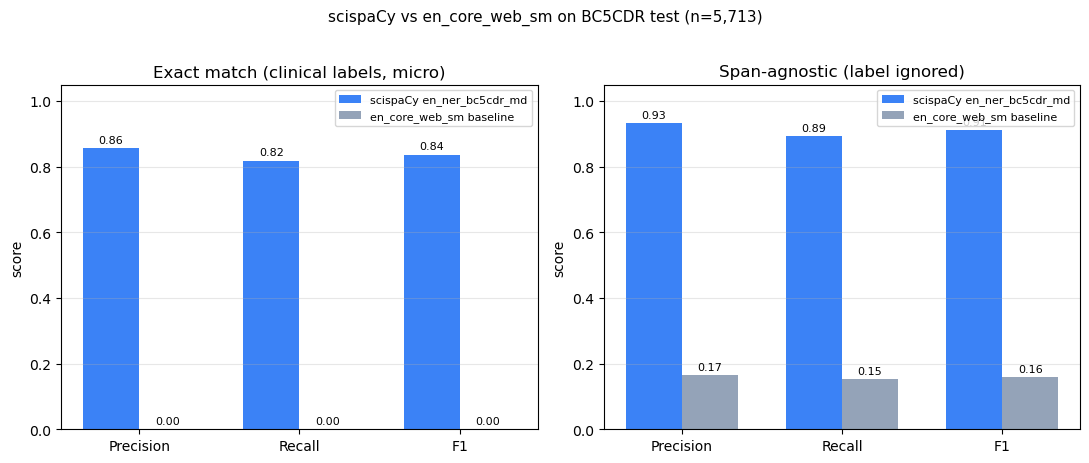

saved images


In [15]:
import matplotlib.pyplot as plt

# Where to save the PNG -- results/ is the project's standard artifact directory
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
chart_path = RESULTS_DIR / "ner_eval_chart.png"

# Shared chart settings
metrics = ["Precision", "Recall", "F1"]
x_positions = list(range(len(metrics)))  # bar group centres on the x axis
bar_width = 0.35  # half a slot each side of the centre
sci_color = "#3b82f6"  # blue for the project model
base_color = "#94a3b8"  # grey for the baseline


def draw_bars(ax, sci_vals, base_vals, title):
    """Draw one grouped-bar subplot comparing scispaCy vs baseline on three metrics."""
    sci_bars = ax.bar(
        [i - bar_width / 2 for i in x_positions],
        sci_vals,
        bar_width,
        label="scispaCy en_ner_bc5cdr_md",
        color=sci_color,
    )
    base_bars = ax.bar(
        [i + bar_width / 2 for i in x_positions],
        base_vals,
        bar_width,
        label="en_core_web_sm baseline",
        color=base_color,
    )
    # Numeric labels on top of every bar (so the reader does not have to eyeball the scale)
    for bar_group in (sci_bars, base_bars):
        for bar in bar_group:
            h = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.01,
                f"{h:.2f}",
                ha="center",
                va="bottom",
                fontsize=8,
            )
    ax.set_xticks(x_positions)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("score")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(loc="upper right", fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left subplot: exact match restricted to clinical labels (the primary metric)
draw_bars(
    axes[0], list(sci_micro), list(base_micro), "Exact match (clinical labels, micro)"
)

# Right subplot: span-agnostic (label ignored) -- the fairness check
draw_bars(
    axes[1], list(sci_span_prf), list(base_span_prf), "Span-agnostic (label ignored)"
)

fig.suptitle(
    f"scispaCy vs en_core_web_sm on BC5CDR test (n={len(rows):,})", y=1.02, fontsize=11
)
fig.tight_layout()
fig.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"saved images")